Goal:

Build a non‑linearly separable dataset (concentric circles).

Show a linear SVM fails in original space.

Explicit mapping (polynomial features) → linear model succeeds in mapped space (visualize in 3D).

Kernel SVM (poly/RBF) learns non‑linear boundaries directly.

Random Fourier Features approximate RBF → linear model in mapped space.

In [2]:
# pip install scikit-learn numpy matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Data: concentric circles (not linearly separable)

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_9900\85339986.py:7: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


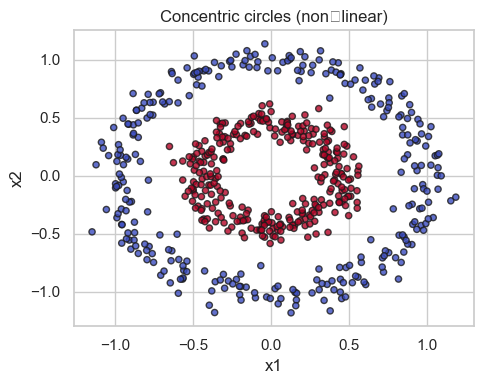

In [3]:
X, y = make_circles(n_samples=600, noise=0.08, factor=0.45, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=20, edgecolor='k', alpha=0.8)
plt.title("Concentric circles (non‑linear)"); plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout(); plt.show()

2) Linear SVM in original space (expected to struggle)

Linear SVM acc (orig space): 0.44


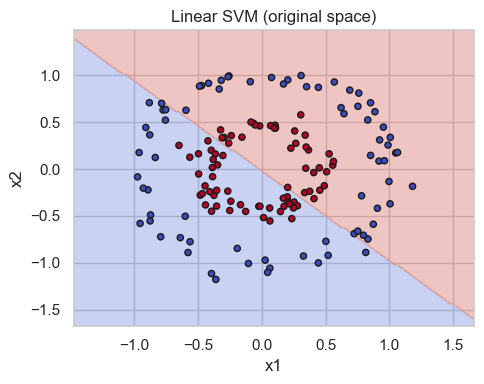

In [4]:
lin = make_pipeline(StandardScaler(), LinearSVC(C=1.0, dual='auto', max_iter=5000)).fit(X_tr, y_tr)
print("Linear SVM acc (orig space):", round(lin.score(X_te, y_te), 3))

# Decision regions
def plot_boundary_2d(model, X, y, title, h=0.02):
    x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
    y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(5,4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', s=20)
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2")
    plt.tight_layout(); plt.show()

plot_boundary_2d(lin, X_te, y_te, "Linear SVM (original space)")

3) Explicit polynomial map (degree 2) → linear separator in mapped space
For circles, the degree‑2 polynomial map

ϕ(x1,x2)=[x12,2x1x2,x22]\phi(x_1,x_2) = \big[x_1^2,\;\sqrt{2}\,x_1x_2,\;x_2^2\big]ϕ(x1​,x2​)=[x12​,2​x1​x2​,x22​]

can make classes (roughly) separable by a plane.

In [5]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
Z_tr = poly2.fit_transform(X_tr)   # columns: [x1, x2, x1^2, x1*x2, x2^2]
Z_te = poly2.transform(X_te)

# Train linear SVM in the mapped (poly) space
lin_poly = LinearSVC(C=1.0, dual='auto', max_iter=5000).fit(Z_tr, y_tr)
print("Linear SVM acc (explicit degree‑2 map):", round(lin_poly.score(Z_te, y_te), 3))

Linear SVM acc (explicit degree‑2 map): 1.0


(Nice!) Visualize the mapping in 3D
Use (x12,2 x1x2,x22)(x_1^2, \sqrt{2}\,x_1x_2, x_2^2)(x12​,2​x1​x2​,x22​) as axes and show the learned separating plan

Linear SVM acc (3D explicit map): 1.0


C:\Users\PRASAD\AppData\Local\Temp\ipykernel_9900\3360864842.py:27: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


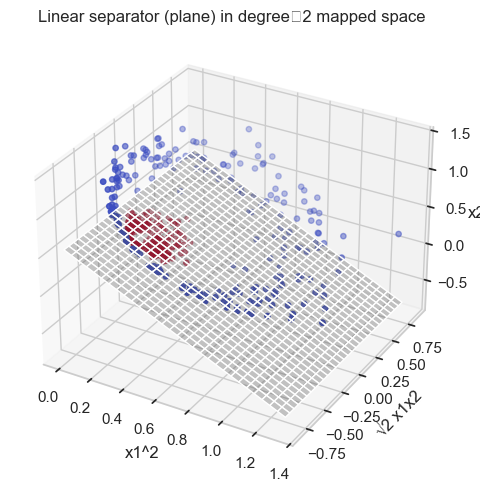

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (for 3D proj)

# Build the classic explicit map with sqrt(2) factor
def phi2(Xin):
    x1, x2 = Xin[:,0], Xin[:,1]
    return np.c_[x1**2, np.sqrt(2)*x1*x2, x2**2]

Phi_tr = phi2(X_tr); Phi_te = phi2(X_te)
clf3d = LinearSVC(C=1.0, dual='auto', max_iter=5000).fit(Phi_tr, y_tr)

acc3d = accuracy_score(y_te, clf3d.predict(Phi_te))
print("Linear SVM acc (3D explicit map):", round(acc3d, 3))

# Plot points and the separating plane
w = clf3d.coef_.ravel(); b = clf3d.intercept_[0]   # plane: w·z + b = 0
xx = np.linspace(Phi_tr[:,0].min(), Phi_tr[:,0].max(), 30)
yy = np.linspace(Phi_tr[:,1].min(), Phi_tr[:,1].max(), 30)
XX, YY = np.meshgrid(xx, yy)
ZZ = (-b - w[0]*XX - w[1]*YY) / (w[2] + 1e-9)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, ZZ, alpha=0.3, color='gray')
ax.scatter(Phi_tr[:,0], Phi_tr[:,1], Phi_tr[:,2], c=y_tr, cmap='coolwarm', s=15)
ax.set_xlabel('x1^2'); ax.set_ylabel('√2 x1x2'); ax.set_zlabel('x2^2')
ax.set_title('Linear separator (plane) in degree‑2 mapped space')
plt.tight_layout(); plt.show()

Takeaway: In the mapped space, a hyperplane corresponds to a non‑linear curve (quadratic) in the original space.

4) Kernel SVMs (no explicit map needed)
Polynomial kernel

SVM (poly degree=2) acc: 1.0


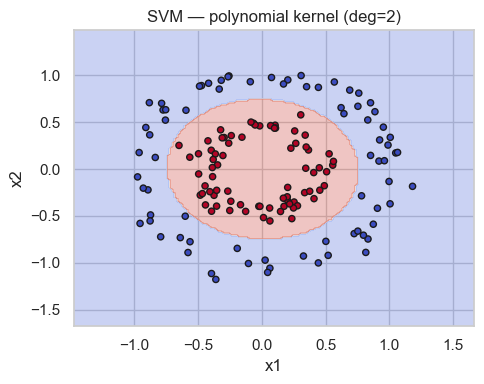

In [7]:
svm_poly = make_pipeline(StandardScaler(), SVC(kernel='poly', degree=2, coef0=1, C=1.0, probability=True, random_state=0)).fit(X_tr, y_tr)
print("SVM (poly degree=2) acc:", round(svm_poly.score(X_te, y_te), 3))
plot_boundary_2d(svm_poly, X_te, y_te, "SVM — polynomial kernel (deg=2)")

RBF kernel

SVM (RBF) acc: 1.0


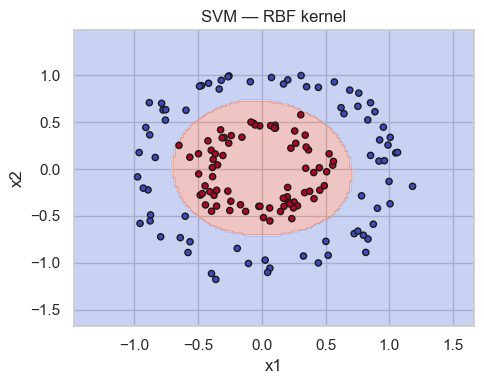

In [8]:
svm_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3.0, gamma='scale', probability=True, random_state=0)).fit(X_tr, y_tr)
print("SVM (RBF) acc:", round(svm_rbf.score(X_te, y_te), 3))
plot_boundary_2d(svm_rbf, X_te, y_te, "SVM — RBF kernel")

Intuition: Kernels compute inner products in a (possibly infinite‑dimensional) feature space, letting us fit a linear separator there without building features explicitly.

5) Random Fourier Features (RFF) ≈ RBF mapping → linear model
Approximate the RBF kernel by mapping to DDD-dim random features and training a linear model.

Linear (RFF approx RBF) acc: 0.987


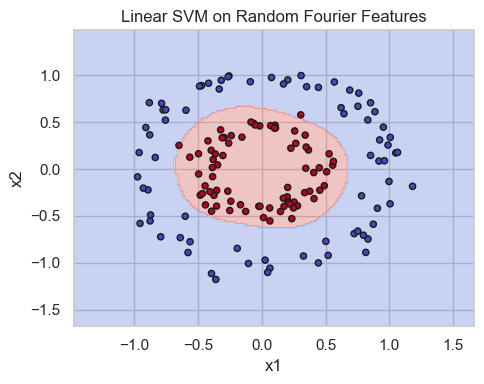

In [9]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier

rff = RBFSampler(gamma=1.0, n_components=500, random_state=0)   # gamma ~ 1/length^2
pipe_rff = make_pipeline(StandardScaler(), rff, SGDClassifier(loss='hinge', alpha=1e-4, max_iter=2000, random_state=0))
pipe_rff.fit(X_tr, y_tr)
print("Linear (RFF approx RBF) acc:", round(pipe_rff.score(X_te, y_te), 3))
plot_boundary_2d(pipe_rff, X_te, y_te, "Linear SVM on Random Fourier Features")

Note: As n_components ↑, RFF better approximates RBF; performance should approach the kernel SVM’s.

Vary degree in the polynomial kernel (2, 3, 4). Plot decision boundaries and report test accuracy. When does higher degree overfit?



Performance Report:
------------------------------
Polynomial Degree 2: Test Accuracy = 0.8667
Polynomial Degree 3: Test Accuracy = 0.9222


C:\Users\PRASAD\AppData\Local\Temp\ipykernel_9900\1141302280.py:55: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm, marker='x', alpha=0.3)
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_9900\1141302280.py:55: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm, marker='x', alpha=0.3)
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_9900\1141302280.py:55: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the futur

Polynomial Degree 4: Test Accuracy = 0.9333


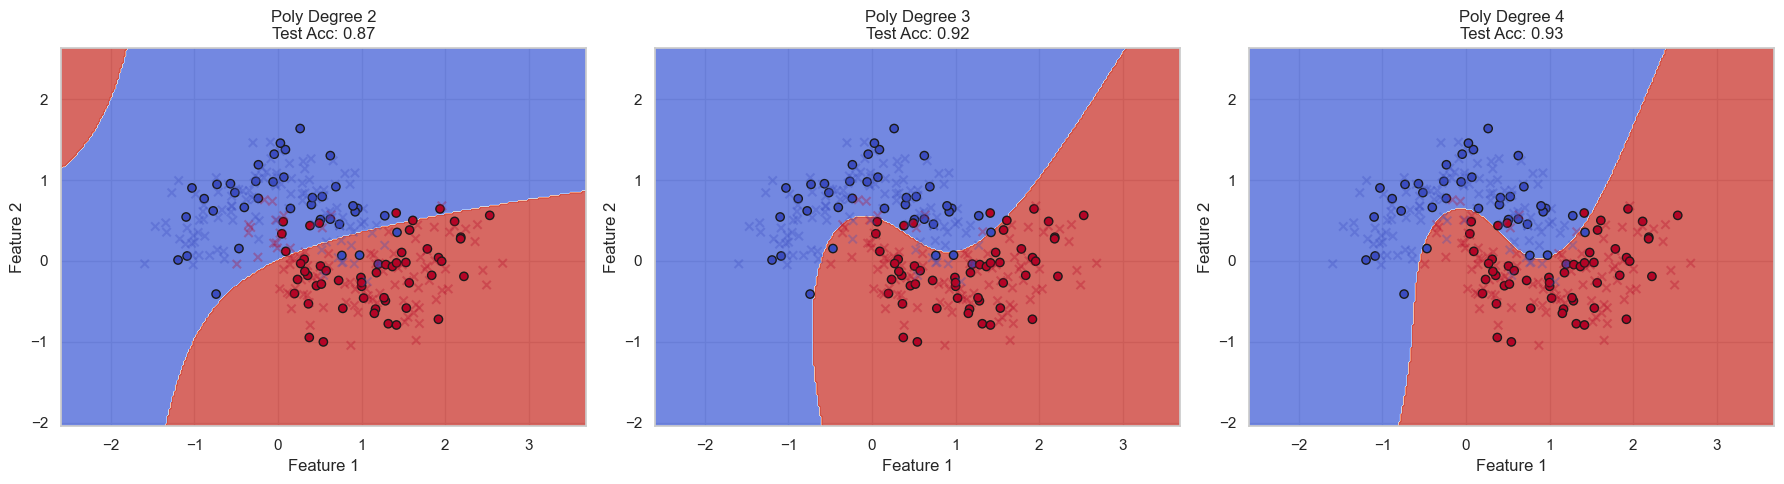

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generate synthetic non-linear data
# We use make_moons because it requires a non-linear boundary
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Degrees to evaluate
degrees = [2, 3, 4]

# Setup the plot
plt.figure(figsize=(18, 5))

# Create a meshgrid for plotting decision boundaries
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

print("Performance Report:")
print("-" * 30)

for i, d in enumerate(degrees):
    # 3. Initialize and Train SVM
    # coef0=1 is important for poly kernels (allows interaction terms + bias)
    clf = SVC(kernel='poly', degree=d, C=1.0, coef0=1.0)
    clf.fit(X_train, y_train)
    
    # 4. Report Test Accuracy
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Polynomial Degree {d}: Test Accuracy = {acc:.4f}")
    
    # 5. Plot Decision Boundary
    plt.subplot(1, 3, i + 1)
    
    # Predict on the meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contours and scatter points
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm, marker='o', label='Test Data')
    # Optional: Plot training data faintly to see the fit
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm, marker='x', alpha=0.3)
    
    plt.title(f"Poly Degree {d}\nTest Acc: {acc:.2f}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()


Tune RBF: grid over C ∈ {0.3, 1, 3, 10} and gamma ∈ {0.2, 0.5, 1.0, 'scale'}; heatmap accuracy.

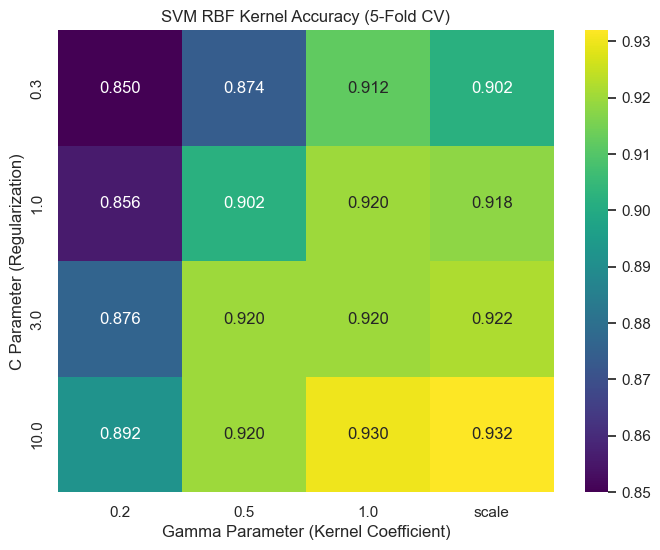

Best Parameters: {'C': 10, 'gamma': 'scale'}
Best Accuracy: 0.9320


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_moons

# 1. Generate synthetic data
# We use make_moons as it benefits from the RBF kernel's non-linear capabilities
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# 2. Define the parameter grid
# 'scale' is a string option in sklearn, while the others are floats
param_grid = {
    'C': [0.3, 1, 3, 10],
    'gamma': [0.2, 0.5, 1.0, 'scale']
}

# 3. Run Grid Search with Cross-Validation
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

# 4. Extract results into a Pandas DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# 5. Pivot the data for the heatmap
# We map C to rows (index) and gamma to columns
heatmap_data = results_df.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

# 6. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".3f")
plt.title('SVM RBF Kernel Accuracy (5-Fold CV)')
plt.ylabel('C Parameter (Regularization)')
plt.xlabel('Gamma Parameter (Kernel Coefficient)')
plt.show()

# Optional: Print best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")


Explanation
Data Preparation: We use make_moons to create a non-linear classification problem.
GridSearchCV: This function automates the "tuning" process. It trains a separate SVM for every combination of $C$ and $\gamma$ defined in param_grid.
Pivot Table: The raw results from cv_results_ are a list of rows. We use pandas.pivot to transform this into a 2D matrix where rows represent $C$ values and columns represent $\gamma$ values.
Heatmap: seaborn.heatmap visualizes this matrix. Lighter/brighter colors (depending on the viridis map) indicate higher accuracy.
Key Takeaways on Parameters
C: Controls the trade-off between a smooth decision boundary and classifying training points correctly. Higher $C$ aims to classify all training examples correctly (risk of overfitting).
Gamma: Defines how far the influence of a single training example reaches. Low values mean 'far' and high values mean 'close'. High gamma leads to tighter decision boundaries around data points.
Generated by G

RFF sweep: try n_components ∈ {50, 200, 500, 1000} with fixed gamma=1.0. Plot accuracy vs n_components and comment on variance/compute.

n_comp     | Accuracy   | Time (s)  
-----------------------------------
50         | 0.9633     | 0.0162
200        | 0.9717     | 0.0287
500        | 0.9683     | 0.0637
1000       | 0.9683     | 0.1417


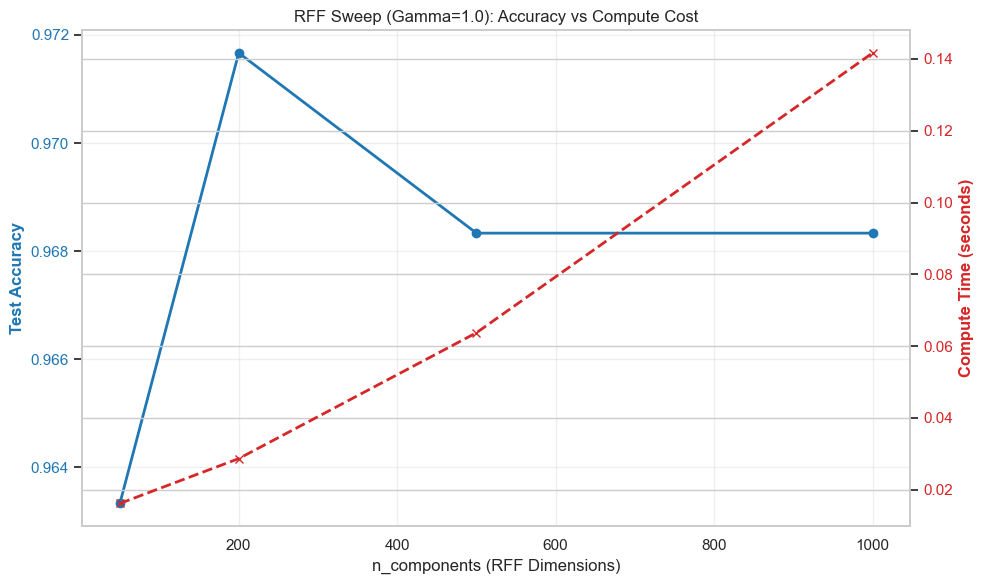

In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.kernel_approximation import RBFSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# 1. Generate Data
# Increased sample size slightly to make compute time differences more noticeable
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Sweep Parameters
n_components_list = [50, 200, 500, 1000]
gamma_val = 1.0

accuracies = []
compute_times = []

print(f"{'n_comp':<10} | {'Accuracy':<10} | {'Time (s)':<10}")
print("-" * 35)

for n in n_components_list:
    start_time = time.time()
    
    # A. Transform input space to RFF space
    # This approximates the feature map of an RBF kernel
    rff_feature = RBFSampler(gamma=gamma_val, n_components=n, random_state=42)
    X_train_rff = rff_feature.fit_transform(X_train)
    X_test_rff = rff_feature.transform(X_test)
    
    # B. Train Linear SVM
    # We use a linear solver because the non-linearity is handled by the RFF mapping
    clf = LinearSVC(dual='auto', max_iter=5000, random_state=42)
    clf.fit(X_train_rff, y_train)
    
    # C. Evaluate
    acc = clf.score(X_test_rff, y_test)
    
    elapsed = time.time() - start_time
    accuracies.append(acc)
    compute_times.append(elapsed)
    
    print(f"{n:<10} | {acc:.4f}     | {elapsed:.4f}")

# 3. Plot Accuracy and Compute Time
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Accuracy (Left Y-Axis)
color = 'tab:blue'
ax1.set_xlabel('n_components (RFF Dimensions)')
ax1.set_ylabel('Test Accuracy', color=color, fontweight='bold')
ax1.plot(n_components_list, accuracies, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot Compute Time (Right Y-Axis)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Compute Time (seconds)', color=color, fontweight='bold')  
ax2.plot(n_components_list, compute_times, marker='x', linestyle='--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'RFF Sweep (Gamma={gamma_val}): Accuracy vs Compute Cost')
plt.tight_layout()
plt.show()


Replace circles with moons (make_moons(noise=0.25)), repeat Sections 2–5, and compare which mapping/kernel works best.

Running Polynomial Kernel Experiment...
Running RBF Grid Search...
Running RFF Sweep...


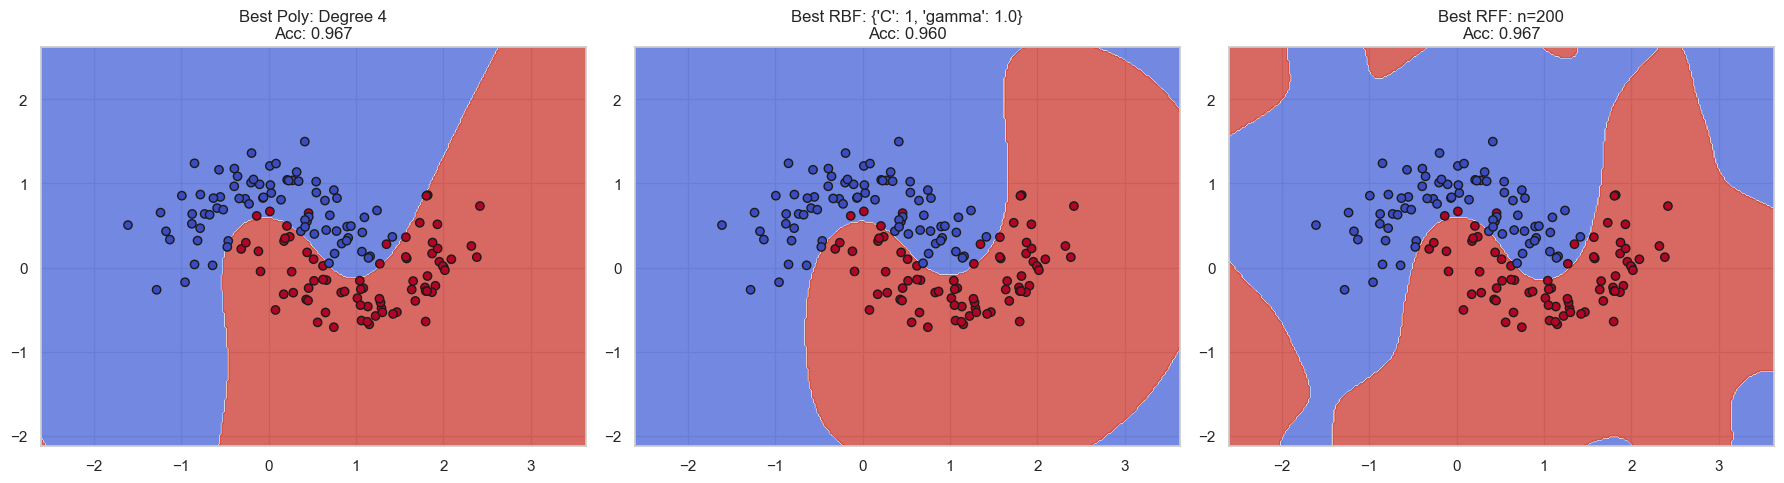


--- Final Comparison ---
                       Method  Accuracy
0                Poly (Deg 4)  0.966667
2                 RFF (n=200)  0.966667
1  RBF {'C': 1, 'gamma': 1.0}  0.960000


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score

# 1. Generate Data (Moons instead of Circles)
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Setup plotting grid
h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_summary = []

# --- SECTION 2: Polynomial Kernel (Vary Degree) ---
print("Running Polynomial Kernel Experiment...")
best_poly_acc = 0
best_poly_model = None
best_poly_deg = 0

for d in [2, 3, 4]:
    # coef0=1 is crucial for poly kernels to handle lower-order interactions
    clf = SVC(kernel='poly', degree=d, C=1.0, coef0=1.0)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    
    if acc > best_poly_acc:
        best_poly_acc = acc
        best_poly_model = clf
        best_poly_deg = d

results_summary.append({'Method': f'Poly (Deg {best_poly_deg})', 'Accuracy': best_poly_acc})

# Plot Best Poly
Z = best_poly_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm)
axes[0].set_title(f"Best Poly: Degree {best_poly_deg}\nAcc: {best_poly_acc:.3f}")

# --- SECTION 3: RBF Kernel (Grid Search) ---
print("Running RBF Grid Search...")
param_grid = {'C': [0.3, 1, 3, 10], 'gamma': [0.2, 0.5, 1.0, 'scale']}
grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train, y_train)

best_rbf_model = grid.best_estimator_
best_rbf_acc = best_rbf_model.score(X_test, y_test)
results_summary.append({'Method': f"RBF {grid.best_params_}", 'Accuracy': best_rbf_acc})

# Plot Best RBF
Z = best_rbf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm)
axes[1].set_title(f"Best RBF: {grid.best_params_}\nAcc: {best_rbf_acc:.3f}")

# --- SECTION 4: RFF Approximation (Sweep n_components) ---
print("Running RFF Sweep...")
best_rff_acc = 0
best_rff_model = None
best_rff_n = 0
best_rff_transformer = None

# Fixed gamma for RFF to match a standard RBF scale
gamma_val = 1.0 

for n in [50, 200, 500, 1000]:
    rff = RBFSampler(gamma=gamma_val, n_components=n, random_state=42)
    X_train_rff = rff.fit_transform(X_train)
    X_test_rff = rff.transform(X_test)
    
    clf = LinearSVC(dual='auto', max_iter=5000, random_state=42)
    clf.fit(X_train_rff, y_train)
    acc = clf.score(X_test_rff, y_test)
    
    if acc > best_rff_acc:
        best_rff_acc = acc
        best_rff_model = clf
        best_rff_n = n
        best_rff_transformer = rff

results_summary.append({'Method': f'RFF (n={best_rff_n})', 'Accuracy': best_rff_acc})

# Plot Best RFF
# Note: Must transform meshgrid points before prediction
Z_rff = best_rff_transformer.transform(np.c_[xx.ravel(), yy.ravel()])
Z = best_rff_model.predict(Z_rff)
Z = Z.reshape(xx.shape)
axes[2].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
axes[2].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm)
axes[2].set_title(f"Best RFF: n={best_rff_n}\nAcc: {best_rff_acc:.3f}")

# --- Comparison Report ---
plt.tight_layout()
plt.show()

print("\n--- Final Comparison ---")
df_results = pd.DataFrame(results_summary)
print(df_results.sort_values(by='Accuracy', ascending=False))
